In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('water_potability.csv') 
print("--- Dimensi Dataset ---")
print(f"Jumlah Baris: {df.shape[0]}, Jumlah Kolom: {df.shape[1]}")

print("\n--- Kolom yang Memiliki Missing Values ---")
missing_info = df.isnull().sum()
print(missing_info[missing_info > 0])

print("\n--- Cek Data Duplikat ---")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

--- Dimensi Dataset ---
Jumlah Baris: 3276, Jumlah Kolom: 10

--- Kolom yang Memiliki Missing Values ---
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

--- Cek Data Duplikat ---
Jumlah baris duplikat: 0


In [2]:
df_clean = df.copy()
df_clean['ph'] = df_clean['ph'].fillna(df_clean['ph'].median())
df_clean['Sulfate'] = df_clean['Sulfate'].fillna(df_clean['Sulfate'].median())
df_clean['Trihalomethanes'] = df_clean['Trihalomethanes'].fillna(df_clean['Trihalomethanes'].median())

print("--- Jumlah Missing Values Setelah Imputasi ---")
print(df_clean.isnull().sum())

--- Jumlah Missing Values Setelah Imputasi ---
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [4]:
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['Potability']) if 'Potability' in df_clean.columns else df_clean.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("--- 5 Data Teratas Setelah Di-scaling ---")
print(X_scaled_df.head())

--- 5 Data Teratas Setelah Di-scaling ---
         ph  Hardness    Solids  Chloramines   Sulfate  Conductivity  \
0 -0.025474  0.259195 -0.139471     0.112415  0.965957      1.708954   
1 -2.284717 -2.036414 -0.385987    -0.307694 -0.014799      2.062575   
2  0.697319  0.847665 -0.240047     1.360594 -0.014799     -0.094032   
3  0.845393  0.547651  0.000493     0.592008  0.644130     -0.778830   
4  1.372982 -0.464429 -0.460249    -0.363698 -0.649522     -0.343939   

   Organic_carbon  Trihalomethanes  Turbidity  
0       -1.180651         1.305434  -1.286298  
1        0.270597        -0.639186   0.684218  
2        0.781117         0.000800  -1.167365  
3        1.255134         2.152154   0.848412  
4       -0.824357        -2.182297   0.138786  


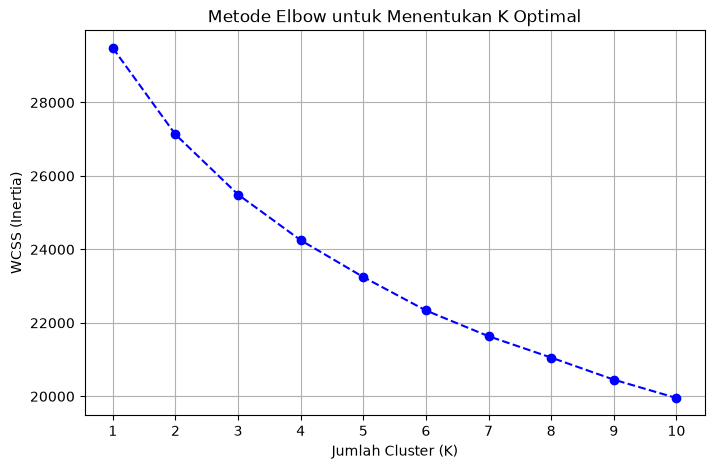

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Visualisasi 
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

--- Evaluasi Model ---
Silhouette Score untuk K=3: 0.0727

--- Jumlah Data per Cluster ---
Cluster
1    1184
0    1175
2     917
Name: count, dtype: int64


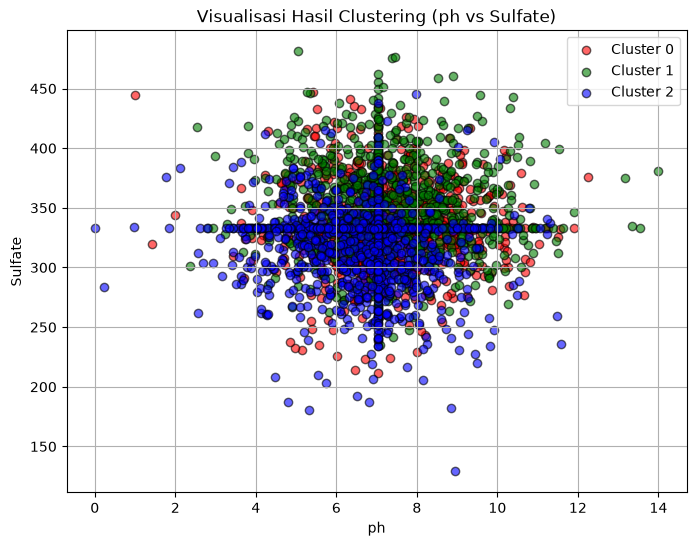

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1.Fit K-Means dengan K=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

# 2.Evaluasi Nilai Silhouette Score
score = silhouette_score(X_scaled, df_clean['Cluster'])
print(f"--- Evaluasi Model ---")
print(f"Silhouette Score untuk K=3: {score:.4f}")

# 3. Cek Jumlah Anggota per Cluster
print("\n--- Jumlah Data per Cluster ---")
print(df_clean['Cluster'].value_counts())

# 4. Visualisasi : ph vs Sulfate
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for cluster in range(3):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    plt.scatter(cluster_data['ph'], cluster_data['Sulfate'], 
                label=f'Cluster {cluster}', alpha=0.6, c=colors[cluster], edgecolors='k')

plt.title('Visualisasi Hasil Clustering (ph vs Sulfate)')
plt.xlabel('ph')
plt.ylabel('Sulfate')
plt.legend()
plt.grid(True)
plt.show()